# Building the DataFrame & training a Naive model for forecasting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sktime.forecasting.naive import NaiveForecaster
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from scipy.special import inv_boxcox
from scipy.stats import boxcox
import pmdarima as pm




from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [2]:
df = pd.read_csv("ECG.csv")

In [3]:
df["ecg_value"] = pd.to_numeric(df["ecg_value"])


In [4]:
display(df.head())

,time,ecg_value
0,0.000,496
1,0.001,496
2,0.002,497
3,0.003,498
4,0.004,498


In [5]:
train = df["ecg_value"][:-int(0.2*len(df))]
test = df["ecg_value"][-int(0.2*len(df)):]
train_df = df[:-int(0.2*len(df))]
test_df = df[-int(0.2*len(df)):]
time_stamps = int(0.2*len(df))+1

In [6]:
baseline_model = NaiveForecaster(strategy="mean")
baseline_model.fit(train)
y_pred = baseline_model.predict(fh=[i for i in range(1,time_stamps)])

In [7]:
prediction = pd.DataFrame({"ecg_value":y_pred})
prediction["time"] = test_df["time"]

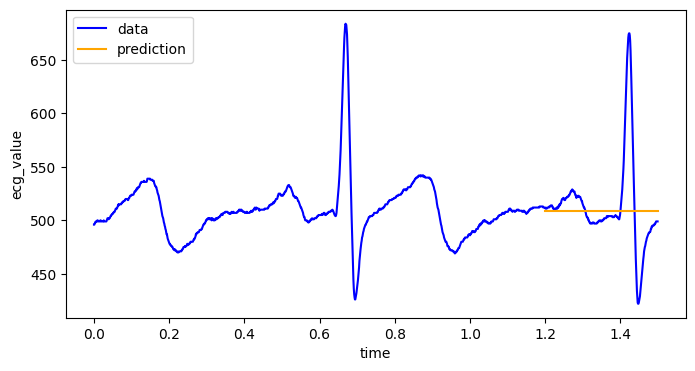

In [8]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="time",y="ecg_value",color="blue",label="data")
sns.lineplot(data=prediction,x="time",y="ecg_value",color="orange",label="prediction")
plt.show()

In [53]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 24.118933333333334
RMSE: 42.85713152116252
MAPE: 0.0450651940229193


# Using a more sophisticated model (ARIMA) and computing the performence metrics

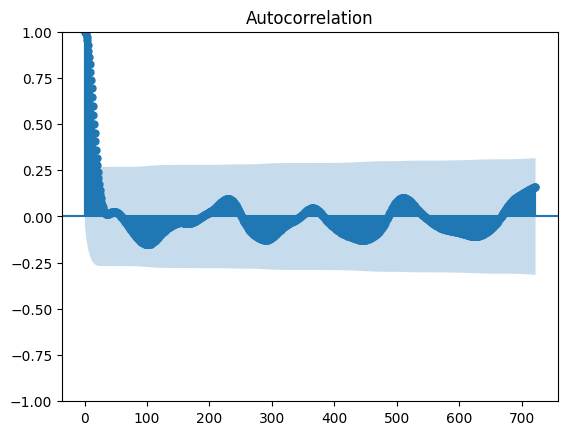

In [54]:
plot_acf(train,lags=722)
plt.show()

In [55]:
model_arima = ARIMA(train,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [56]:
prediction = pd.DataFrame({"ecg_value":y_pred})
prediction["time"] = test_df["time"]

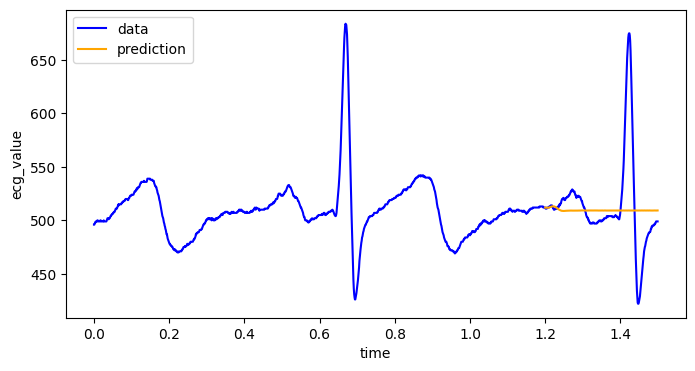

In [57]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="time",y="ecg_value",color="blue",label="data")
sns.lineplot(data=prediction,x="time",y="ecg_value",color="orange",label="prediction")
plt.show()

In [58]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 23.93717516035873
RMSE: 42.855320753304774
MAPE: 0.04470987343248203


# Testing a different refinement method each time and looking at the performence

* The Box Cox

In [59]:
train_BoxCox, lam = boxcox(train)
model_arima = ARIMA(train_BoxCox,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))
y_pred = inv_boxcox(y_pred,lam)

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [60]:
prediction = pd.DataFrame({"ecg_value":y_pred})
prediction.index = range(1200,1200+len(prediction))
prediction["time"] = test_df["time"]

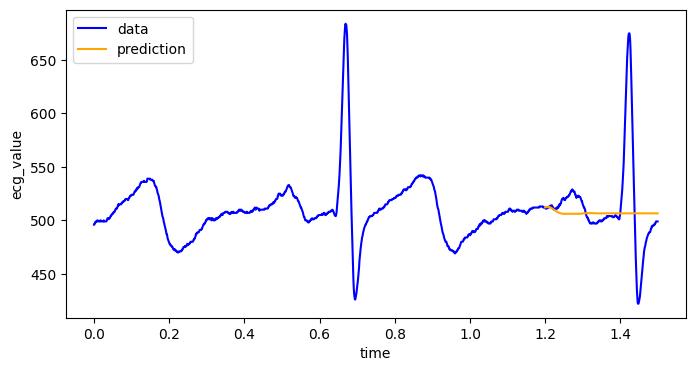

In [61]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="time",y="ecg_value",color="blue",label="data")
sns.lineplot(data=prediction,x="time",y="ecg_value",color="orange",label="prediction")
plt.show()

In [62]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 23.676199517178908
RMSE: 43.16451722119822
MAPE: 0.04396413331158315


* IQR impuration with the median

In [63]:
median = np.median(train)
train_IQR = train.copy()
for i in range(len(train_IQR)):
    if train_IQR[i]>median*1.5:
        train_IQR[i] = median
        

In [64]:
model_arima = ARIMA(train_IQR,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [65]:
prediction = pd.DataFrame({"ecg_value":y_pred})
prediction["time"] = test_df["time"]

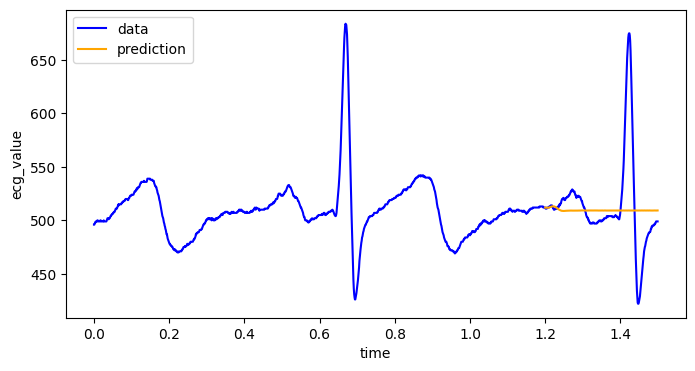

In [66]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="time",y="ecg_value",color="blue",label="data")
sns.lineplot(data=prediction,x="time",y="ecg_value",color="orange",label="prediction")
plt.show()

In [67]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 23.93717516035873
RMSE: 42.855320753304774
MAPE: 0.04470987343248203


* Fourier Trend

In [68]:
df_fourier = df.copy()

In [69]:
for order in range(1,10):
    df_fourier[f"fourier_sin_order_{order}"] = np.sin(2* np.pi * order * df_fourier["time"]*10)
    df_fourier[f"fourier_cos_order_{order}"] = np.cos(2* np.pi * order * df_fourier["time"]*10)
    
fourier_features = [i for i in list(df_fourier) if i.startswith("fourier")]
train_df_fourier = df_fourier[:-int(0.2*len(df))]
test_df_fourier = df_fourier[-int(0.2*len(df)):]

In [70]:
model = pm.auto_arima(
    train_df_fourier["ecg_value"],
    X = train_df_fourier[fourier_features],
    seasonal = False,
    stepwise = True,
    suppress_warnings = True,
    max_order = None,
    information_criterion = "aicc",
    error_action = "ignore"
)
y_pred = model.predict(n_periods = len(test_df_fourier), X=test_df_fourier[fourier_features])

In [71]:
prediction = pd.DataFrame({"ecg_value":y_pred})
prediction["time"] = test_df["time"]

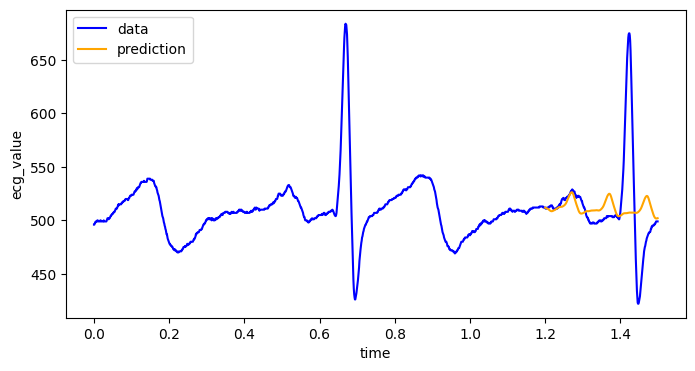

In [72]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df_fourier,x="time",y="ecg_value",color="blue",label="data")
sns.lineplot(data=prediction,x="time",y="ecg_value",color="orange",label="prediction")
plt.show()

In [73]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 24.345333125465597
RMSE: 43.96019200395677
MAPE: 0.045607247299966985


* Seasonal Differencing

In [22]:
df_diff = df.copy()
df_diff["ecg_value"] = df["ecg_value"].diff(722)
df_diff["time"] = df["time"]

train_diff = df["ecg_value"][:-int(0.2*len(df))]
test_diff = df["ecg_value"][-int(0.2*len(df)):]

train_diff.dropna(inplace=True)

In [30]:
train_diff = df_diff["ecg_value"]
train_diff.dropna(inplace=True)

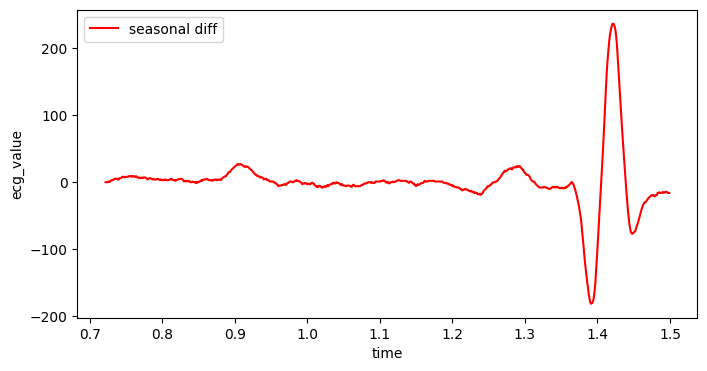

In [35]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df_diff,x="time",y="ecg_value",color="red",label="seasonal diff")
plt.show()

In [76]:
model_arima = ARIMA(train_diff,order=(20,0,20))
model_arima = model_arima.fit()
y_pred_diff = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [77]:
y_pred_diff = list(y_pred_diff)

In [78]:
y_pred = []
for i in range(len(test)):
    if i<722:
        value = df.iloc[int(-len(df)*0.2)-722+i].loc["ecg_value"]
        y_pred.append(y_pred_diff[i]+value)
    else:
        y_pred.append(y_pred_diff[i]+y_pred[-722])
        

In [79]:
prediction = pd.DataFrame({"ecg_value":y_pred})
prediction.index = range(1200,1200+len(test))
prediction["time"] = test_df["time"]


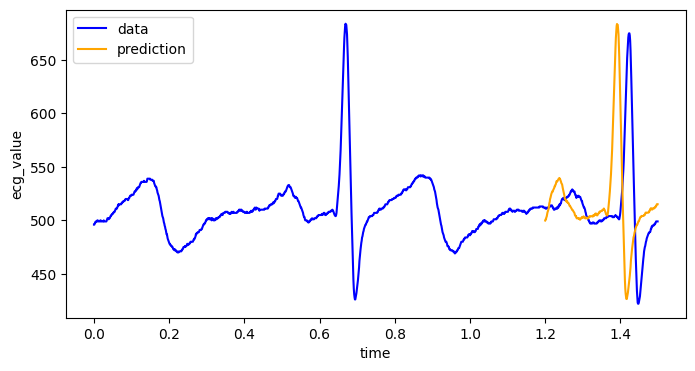

In [80]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="time",y="ecg_value",color="blue",label="data")
sns.lineplot(data=prediction,x="time",y="ecg_value",color="orange",label="prediction")
plt.show()

In [81]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 41.69482706899364
RMSE: 71.22087716696404
MAPE: 0.07757499498545485
